# LHNAUTICALS: Diagnóstico e Alavancas de Crescimento
#### **Autor**: Leonardo Farias dos Santos

---

Sumário: A LH Nauticals tem uma operação com dados fragmentados que escondem ineficiências logísticas e comerciais. Ao consolidar esses dados, descobrimos que a empresa perde dinheiro com ociosidade em dias específicos e um modelo de precificação estático que não acompanha a flutuação cambial. No entanto, com a implementação de um sistema de recomendação cruzada, existe uma avenida clara para recuperar essa receita e aumentar o ticket médio.

In [1]:
# ==========================================
# SETUP
# ==========================================

import json
from pathlib import Path

import pandas as pd
import duckdb
import requests
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from sklearn.metrics import mean_absolute_error
from sklearn.metrics.pairwise import cosine_similarity

# Assuming the notebook is executed from the project's root directory.
BASE_DIR = Path.cwd().parent
RAW_DIR = BASE_DIR / 'data' / 'raw'
PROCESSED_DIR = BASE_DIR / 'data' / 'processed'

df_sales = pd.read_csv(RAW_DIR / 'vendas_2023_2024.csv')
df_products = pd.read_csv(PROCESSED_DIR / 'produtos_processed.csv')
df_costs = pd.read_csv(PROCESSED_DIR / 'custos_importacao_processed.csv')

with open(RAW_DIR / 'clientes_crm.json', 'r', encoding='utf-8') as f:
    df_clients = pd.DataFrame(json.load(f))

df_sales['sale_date'] = pd.to_datetime(df_sales['sale_date'], format='mixed', dayfirst=True).dt.date
df_costs['start_date'] = pd.to_datetime(df_costs['start_date'], format='mixed', dayfirst=True).dt.date

def fetch_exchange_rates(start_date: str, end_date: str) -> pd.DataFrame:
    url = (
        f"https://olinda.bcb.gov.br/olinda/servico/PTAX/versao/v1/odata/"
        f"CotacaoDolarPeriodo(dataInicial=@dataInicial,dataFinalCotacao=@dataFinalCotacao)?"
        f"@dataInicial='{start_date}'&@dataFinalCotacao='{end_date}'&$format=json"
    )
    
    response = requests.get(url)
    response.raise_for_status() 
    
    data = response.json()['value']
    df_api = pd.DataFrame(data)
    
    df_api = df_api[['dataHoraCotacao', 'cotacaoVenda']].rename(
        columns={'dataHoraCotacao': 'rate_date', 'cotacaoVenda': 'usd_rate'}
    )
    
    df_api['rate_date'] = pd.to_datetime(df_api['rate_date']).dt.date
    
    return df_api

df_rates = fetch_exchange_rates("01-01-2023", "12-31-2024")

print(f"✔ Sales loaded: {len(df_sales)} records")
print(f"✔ Products loaded: {len(df_products)} records")
print(f"✔ Clients loaded: {len(df_clients)} records")
print(f"✔ Exchange Rates loaded: {len(df_rates)} business days")

✔ Sales loaded: 9895 records
✔ Products loaded: 150 records
✔ Clients loaded: 49 records
✔ Exchange Rates loaded: 502 business days


## Fase 1: Visão Geral e Saúde do Negócio (Snapshot Atual)
Antes de mergulharmos nos diagnósticos específicos, precisamos entender o tamanho da nossa operação e como ela se distribui. Esta seção apresenta os principais KPIs (Key Performance Indicators) consolidados de todo o período analisado.

### 1.1 Principais KPIs

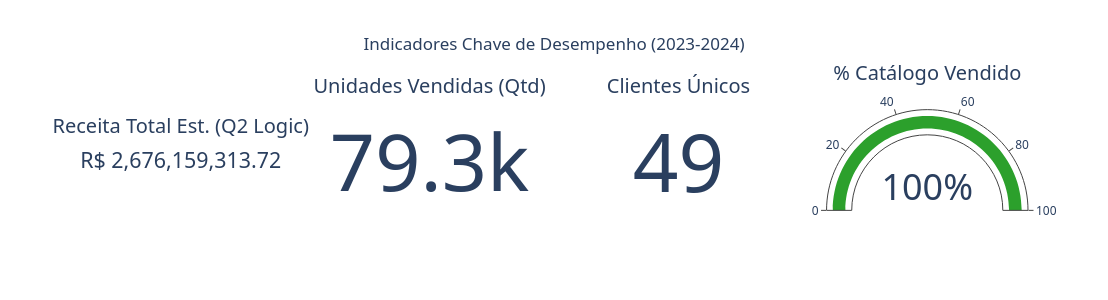

In [2]:
# ==========================================
# DATA PREPARATION
# ==========================================

total_units_sold = df_sales['qtd'].sum()
total_products_catalog = df_products['code'].nunique()
total_products_sold = df_sales['id_product'].nunique()
total_customers = df_sales['id_client'].nunique()

catalog_coverage = (total_products_sold / total_products_catalog) * 100

try:
    total_revenue_exec = (df_sales.groupby('id_product')['qtd'].sum() * df_products.set_index('code')['price']).sum()
except:
    total_revenue_exec = 0 

# ==========================================
# VISUALIZATION
# ==========================================

fig_kpis = make_subplots(
    rows=1, cols=4,
    specs=[[{'type': 'indicator'}, {'type': 'indicator'}, {'type': 'indicator'}, {'type': 'indicator'}]]
)

fig_kpis.add_trace(go.Indicator(
    mode="number",
    value=total_revenue_exec,
    number={'prefix': "R$ ", 'valueformat': ",.2f"},
    title={"text": "Receita Total Est. (Q2 Logic)"}
), row=1, col=1)

fig_kpis.add_trace(go.Indicator(
    mode="number",
    value=total_units_sold,
    title={"text": "Unidades Vendidas (Qtd)"}
), row=1, col=2)

fig_kpis.add_trace(go.Indicator(
    mode="number",
    value=total_customers,
    title={"text": "Clientes Únicos"}
), row=1, col=3)

fig_kpis.add_trace(go.Indicator(
    mode="number+gauge",
    value=catalog_coverage,
    number={'suffix': "%"},
    gauge={'axis': {'range': [0, 100]}, 'bar': {'color': "#2ca02c"}},
    title={"text": "% Catálogo Vendido"}
), row=1, col=4)

fig_kpis.update_layout(
    title_text="Indicadores Chave de Desempenho (2023-2024)",
    title_x=0.5,
    height=300,
    plot_bgcolor='white'
)

fig_kpis.show()

### 1.2 Visão Ampliada

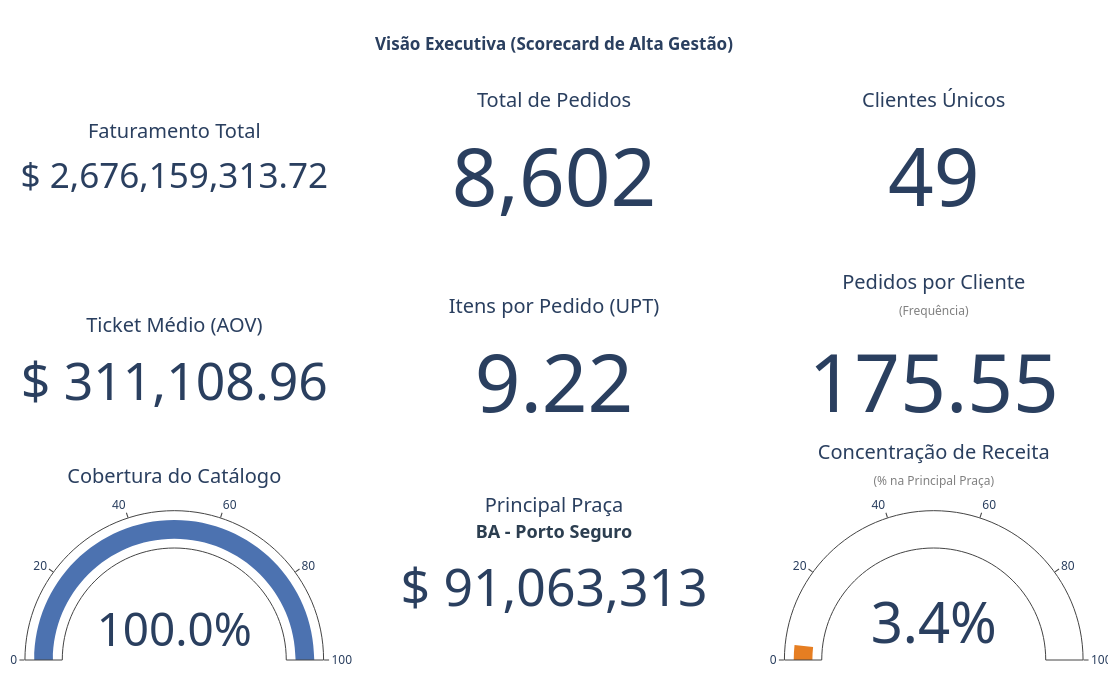

In [3]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# ==========================================
# DATA PREPARATION
# ==========================================
if 'price' not in df_sales.columns:
    df_sales = df_sales.merge(
        df_products[['code', 'price']], 
        left_on='id_product', 
        right_on='code', 
        how='left'
    )

if 'location' not in df_sales.columns:
    df_sales = df_sales.merge(
        df_clients[['code', 'location']], 
        left_on='id_client', 
        right_on='code',
        how='left'
    )

df_sales['revenue'] = df_sales['qtd'] * df_sales['price']
total_revenue = df_sales['revenue'].sum()
total_units_sold = df_sales['qtd'].sum()
total_products_catalog = df_products['code'].nunique()
total_products_sold = df_sales['id_product'].nunique()
total_customers = df_sales['id_client'].nunique()

df_sales['order_id'] = df_sales['id_client'].astype(str) + '_' + df_sales['sale_date'].astype(str)
total_orders = df_sales['order_id'].nunique()

catalog_coverage = (total_products_sold / total_products_catalog) * 100
average_ticket = total_revenue / total_orders if total_orders > 0 else 0
units_per_order = total_units_sold / total_orders if total_orders > 0 else 0

purchase_frequency = total_orders / total_customers if total_customers > 0 else 0

df_geo = df_sales.groupby('location')['revenue'].sum().reset_index()
top_location_name = df_geo.loc[df_geo['revenue'].idxmax(), 'location']
top_location_revenue = df_geo['revenue'].max()
top_location_share = (top_location_revenue / total_revenue) * 100

# ==========================================
# VISUALIZATION
# ==========================================
fig_kpis = make_subplots(
    rows=3, cols=3,
    specs=[[{'type': 'indicator'}, {'type': 'indicator'}, {'type': 'indicator'}],
           [{'type': 'indicator'}, {'type': 'indicator'}, {'type': 'indicator'}],
           [{'type': 'indicator'}, {'type': 'indicator'}, {'type': 'indicator'}]]
)

fig_kpis.add_trace(go.Indicator(
    mode="number", value=total_revenue,
    number={'prefix': "$ ", 'valueformat': ",.2f"}, 
    title={"text": "Faturamento Total"}
), row=1, col=1)

fig_kpis.add_trace(go.Indicator(
    mode="number", value=total_orders,
    number={'valueformat': ","},
    title={"text": "Total de Pedidos"}
), row=1, col=2)

fig_kpis.add_trace(go.Indicator(
    mode="number", value=total_customers,
    number={'valueformat': ","},
    title={"text": "Clientes Únicos"}
), row=1, col=3)

fig_kpis.add_trace(go.Indicator(
    mode="number", value=average_ticket,
    number={'prefix': "$ ", 'valueformat': ",.2f"},
    title={"text": "Ticket Médio (AOV)"}
), row=2, col=1)

fig_kpis.add_trace(go.Indicator(
    mode="number", value=units_per_order,
    number={'valueformat': ".2f"},
    title={"text": "Itens por Pedido (UPT)"}
), row=2, col=2)

fig_kpis.add_trace(go.Indicator(
    mode="number", value=purchase_frequency,
    number={'valueformat': ".2f"},
    title={"text": "Pedidos por Cliente<br><span style='font-size:12px;color:gray'>(Frequência)</span>"}
), row=2, col=3)

fig_kpis.add_trace(go.Indicator(
    mode="number+gauge", value=catalog_coverage,
    number={'suffix': "%", 'valueformat': ".1f"},
    gauge={'axis': {'range': [0, 100]}, 'bar': {'color': "#4C72B0"}},
    title={"text": "Cobertura do Catálogo"}
), row=3, col=1)

fig_kpis.add_trace(go.Indicator(
    mode="number", value=top_location_revenue,
    number={'prefix': "$ ", 'valueformat': ",.0f"},
    title={"text": f"Principal Praça<br><span style='font-size:18px;color:#2C3E50'><b>{top_location_name}</b></span>"}
), row=3, col=2)

fig_kpis.add_trace(go.Indicator(
    mode="number+gauge", value=top_location_share,
    number={'suffix': "%", 'valueformat': ".1f"},
    gauge={'axis': {'range': [0, 100]}, 'bar': {'color': "#E67E22"}},
    title={"text": "Concentração de Receita<br><span style='font-size:12px;color:gray'>(% na Principal Praça)</span>"}
), row=3, col=3)

fig_kpis.update_layout(
    title_text="<b>Visão Executiva (Scorecard de Alta Gestão)</b>",
    title_x=0.5,
    height=700, 
    plot_bgcolor='white',
    margin=dict(t=100, b=40, l=20, r=20)
)

fig_kpis.show()

### 1.3 Faturamento Mensal

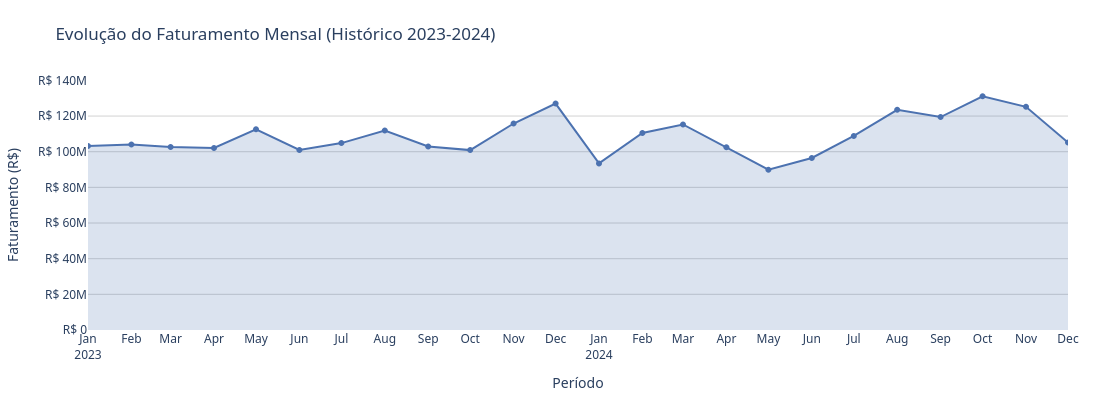

In [4]:
# ==========================================
# DATA PROCESSING
# ==========================================

df_sales['sale_date'] = pd.to_datetime(df_sales['sale_date'])
df_sales['year_month'] = df_sales['sale_date'].dt.to_period('M').dt.to_timestamp()
df_monthly_trend = df_sales.groupby('year_month')['total'].sum().reset_index()

# ==========================================
# 2. Plotly Visualization (Area Chart)
# ==========================================

fig_trend = px.area(
    df_monthly_trend, 
    x='year_month', 
    y='total',
    title='Evolução do Faturamento Mensal (Histórico 2023-2024)',
    labels={'year_month': 'Período', 'total': 'Faturamento (R$)'},
    markers=True
)

fig_trend.update_traces(
    line_color='#4C72B0', 
    fillcolor='rgba(76, 114, 176, 0.2)',
    hovertemplate="<b>%{x|%B %Y}</b><br>Faturamento: R$ %{y:,.2f}<extra></extra>"
)

fig_trend.update_layout(
    plot_bgcolor='white',
    hovermode='x unified',
    height=400,
    margin=dict(t=80, b=40, l=40, r=40),
    xaxis=dict(
        showgrid=False, 
        dtick="M1",
        tickformat="%b\n%Y"
    ),
    yaxis=dict(
        showgrid=True, 
        gridcolor='lightgrey', 
        tickprefix="R$ "
    )
)

fig_trend.show()

### 1.4 - Composição das Vendas ("O que vendemos")

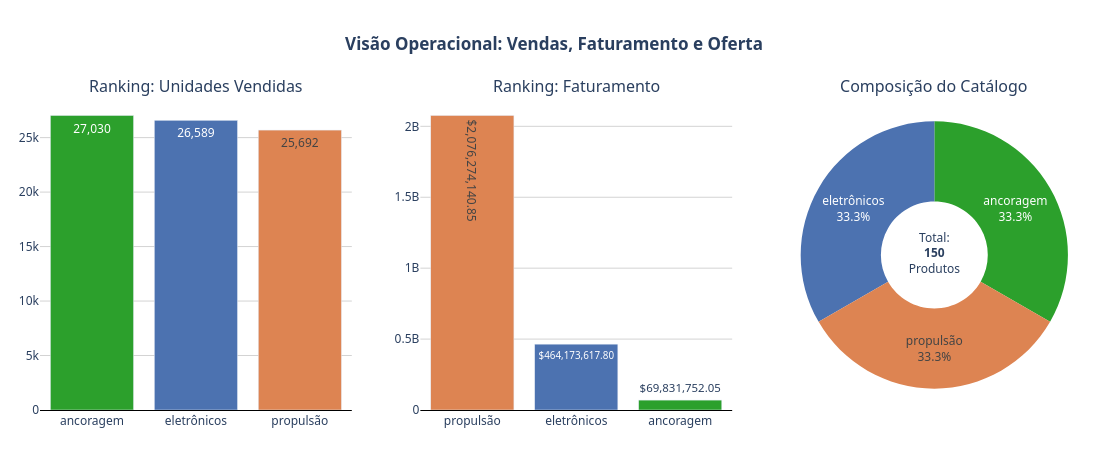

In [6]:

# ==========================================
# DATA PROCESSING
# ==========================================

df_sales_enriched = df_sales.merge(
    df_products[['code', 'actual_category']], 
    left_on='id_product', 
    right_on='code', 
    how='left'
)

df_sales_ranking = df_sales_enriched.groupby('actual_category')['qtd'].sum().reset_index()
df_sales_ranking['qtd'] = df_sales_ranking['qtd'].astype(int) 
df_sales_ranking = df_sales_ranking.sort_values(by='qtd', ascending=False)

df_revenue = df_sales_enriched.groupby('actual_category')['total'].sum().reset_index()
df_revenue = df_revenue.sort_values(by='total', ascending=False)

total_catalog_items = df_products['code'].nunique()
df_catalog_mix = df_products.groupby('actual_category')['code'].nunique().reset_index()
df_catalog_mix.columns = ['actual_category', 'product_count']

color_map = {
    'eletrônicos': '#4C72B0', 
    'propulsão': '#DD8452', 
    'ancoragem': '#2CA02C'
}

sales_colors = df_sales_ranking['actual_category'].map(color_map).tolist()
revenue_colors = df_revenue['actual_category'].map(color_map).tolist()
catalog_colors = df_catalog_mix['actual_category'].map(color_map).tolist()

# ==========================================
# VISUALIZATION
# ==========================================
fig_overview = make_subplots(
    rows=1, cols=3,
    specs=[[{"type": "bar"}, {"type": "bar"}, {"type": "pie"}]],
    subplot_titles=(
        "Ranking: Unidades Vendidas", 
        "Ranking: Faturamento",
        "Composição do Catálogo"
    ),
    column_widths=[0.35, 0.35, 0.30] 
)

# Gráfico 1: Unidades Vendidas
fig_overview.add_trace(
    go.Bar(
        x=df_sales_ranking['actual_category'],
        y=df_sales_ranking['qtd'],
        text=df_sales_ranking['qtd'],
        textposition='auto',
        texttemplate='%{text:,.0f}', 
        marker_color=sales_colors,
        hovertemplate="<b>%{x}</b><br>Vendidos: %{y:,.0f}<extra></extra>"
    ),
    row=1, col=1
)

# Gráfico 2: Faturamento
fig_overview.add_trace(
    go.Bar(
        x=df_revenue['actual_category'],
        y=df_revenue['total'],
        text=df_revenue['total'],
        textposition='auto',
        texttemplate='$%{text:,.2f}', 
        marker_color=revenue_colors,
        hovertemplate="<b>%{x}</b><br>Faturamento: $%{y:,.2f}<extra></extra>"
    ),
    row=1, col=2
)

# Gráfico 3: Catálogo (Itens Únicos)
fig_overview.add_trace(
    go.Pie(
        labels=df_catalog_mix['actual_category'],
        values=df_catalog_mix['product_count'],
        hole=0.4,
        title=f"Total:<br><b>{total_catalog_items}</b><br>Produtos",
        textinfo='label+percent',
        hovertemplate="<b>%{label}</b><br>Itens no Catálogo: %{value}<br>Fatia: %{percent}<extra></extra>",
        marker=dict(colors=catalog_colors) 
    ),
    row=1, col=3
)

# Ajustes de Layout e Eixos
fig_overview.update_layout(
    title_text="<b>Visão Operacional: Vendas, Faturamento e Oferta</b>",
    title_x=0.5,
    showlegend=False,
    height=450,
    width=1200, # Largura expandida para acomodar 3 gráficos sem espremer
    plot_bgcolor='white',
    margin=dict(t=100, b=40, l=40, r=40)
)

fig_overview.update_yaxes(showgrid=True, gridcolor='lightgrey', row=1, col=1)
fig_overview.update_yaxes(showgrid=True, gridcolor='lightgrey', row=1, col=2)
fig_overview.update_xaxes(showline=True, linewidth=1, linecolor='black', row=1, col=1)
fig_overview.update_xaxes(showline=True, linewidth=1, linecolor='black', row=1, col=2)

fig_overview.show()

#### Diagnóstico:

Podemos analisar que temos uma oferta igual de produtos entre as três categorias, em termos de unidades vendidas a diferença é mínima com ancoragem sendo o tipo de item mais vendido contudo os produtos de propulsão são responsáveis pela esmagadora maioria do faturamento.

Uma posível explicação é que existe um alto fator de cross-selling entre as categorias, onde um produto incentiva a compra de outro.


### 1.5 - Perfil da base de clientes.

### 1.5.1 - Quem são os clientes Fiéis?


QUESTÃO 5.2 - Validação 

>> A categoria mais vendida foi a PROPULSÃO, com um total absoluto de 6030 itens comprados.

---------------------------------------------------------------------------
RESUMO DO INDICADOR:
Este volume reflete exclusivamente o padrão de consumo do grupo restrito
de 10 clientes classificados como 'Elite' (carteira filtrada pelo maior
Ticket Médio histórico e com diversidade de produtos adquiridos igual ou superior
a 3 categorias distintas).



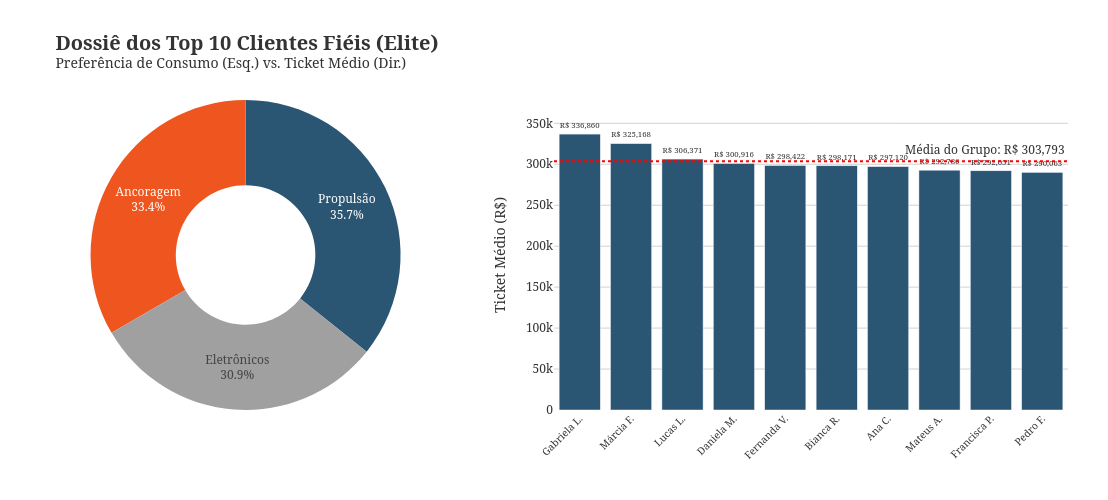

In [7]:
# ==========================================
# DATA PROCESSING
# ==========================================

query_categories = """
-- Table names clarification:
-- df_sales: Represents sales_2023_2024.csv.
-- df_products: Represents produtos_raw.csv (Camada Bronze).

WITH DeduplicatedProducts AS (
    SELECT 
        code AS product_id,
        CASE 
            WHEN LOWER(REPLACE(CAST(actual_category AS VARCHAR), ' ', '')) LIKE '%ele%' THEN 'eletrônicos'
            WHEN LOWER(REPLACE(CAST(actual_category AS VARCHAR), ' ', '')) LIKE '%anc%' 
              OR LOWER(REPLACE(CAST(actual_category AS VARCHAR), ' ', '')) LIKE '%enc%' THEN 'ancoragem'
            WHEN LOWER(REPLACE(CAST(actual_category AS VARCHAR), ' ', '')) LIKE '%prop%' THEN 'propulsão'
            ELSE 'outros' 
        END AS standardized_category,
        ROW_NUMBER() OVER(PARTITION BY code ORDER BY name) AS row_num
    FROM df_products
),
CleanProducts AS (
    SELECT product_id, standardized_category
    FROM DeduplicatedProducts
    WHERE row_num = 1
),
base_data AS (
    SELECT 
        s.id_client, 
        s.id as sell_id, 
        s.total, 
        s.qtd,
        p.standardized_category AS actual_category
    FROM df_sales s
    INNER JOIN CleanProducts p ON s.id_product = p.product_id
),
customer_metrics AS (
    SELECT id_client,
           SUM(total) / NULLIF(COUNT(DISTINCT sell_id), 0) AS average_ticket,
           COUNT(DISTINCT actual_category) AS category_diversity
    FROM base_data
    GROUP BY id_client
),
top_10_elite AS (
    SELECT id_client
    FROM customer_metrics
    WHERE category_diversity >= 3
    -- Desempate pelo id_cliente conforme regra do desafio
    ORDER BY average_ticket DESC, id_client ASC 
    LIMIT 10
)
SELECT b.actual_category, SUM(b.qtd) AS total_items_sold
FROM base_data b
INNER JOIN top_10_elite t ON b.id_client = t.id_client
GROUP BY b.actual_category
ORDER BY total_items_sold DESC;
"""

query_tickets = """
-- Table names clarification:
-- df_sales: Represents sales_2023_2024.csv.
-- df_products: Represents produtos_raw.csv.
-- df_clients: Represents clientes_crm.json.

WITH DeduplicatedProducts AS (
    SELECT 
        code AS product_id,
        CASE 
            WHEN LOWER(REPLACE(CAST(actual_category AS VARCHAR), ' ', '')) LIKE '%ele%' THEN 'eletrônicos'
            WHEN LOWER(REPLACE(CAST(actual_category AS VARCHAR), ' ', '')) LIKE '%anc%' 
              OR LOWER(REPLACE(CAST(actual_category AS VARCHAR), ' ', '')) LIKE '%enc%' THEN 'ancoragem'
            WHEN LOWER(REPLACE(CAST(actual_category AS VARCHAR), ' ', '')) LIKE '%prop%' THEN 'propulsão'
            ELSE 'outros' 
        END AS standardized_category,
        ROW_NUMBER() OVER(PARTITION BY code ORDER BY name) AS row_num
    FROM df_products
),
CleanProducts AS (
    SELECT product_id, standardized_category
    FROM DeduplicatedProducts
    WHERE row_num = 1
),
base_data AS (
    SELECT s.id_client, s.id as sell_id, s.total, p.standardized_category AS actual_category
    FROM df_sales s
    INNER JOIN CleanProducts p ON s.id_product = p.product_id
),
customer_metrics AS (
    SELECT 
        c.full_name AS raw_client_name,
        b.id_client,
        SUM(b.total) / NULLIF(COUNT(DISTINCT b.sell_id), 0) AS average_ticket,
        COUNT(DISTINCT b.actual_category) AS category_diversity
    FROM base_data b
    INNER JOIN df_clients c ON b.id_client = c.code
    GROUP BY c.full_name, b.id_client
)
SELECT raw_client_name, average_ticket
FROM customer_metrics
WHERE category_diversity >= 3
-- Desempate pelo id_cliente ascendente garantido
ORDER BY average_ticket DESC, id_client ASC
LIMIT 10;
"""

df_categories = duckdb.query(query_categories).df()
df_tickets = duckdb.query(query_tickets).df()

if not df_categories.empty:
    top_category = df_categories.iloc[0]
    
    # Extrai as variáveis dinamicamente
    category_name = str(top_category['actual_category']).upper()
    total_items = int(top_category['total_items_sold'])

    print("\n" + "="*75)
    print("QUESTÃO 5.2 - Validação ")
    print("="*75 + "\n")
    
    print(f">> A categoria mais vendida foi a {category_name}, "
          f"com um total absoluto de {total_items} itens comprados.\n")
    
    print("-" * 75)
    print("RESUMO DO INDICADOR:")
    print("Este volume reflete exclusivamente o padrão de consumo do grupo restrito")
    print("de 10 clientes classificados como 'Elite' (carteira filtrada pelo maior")
    print("Ticket Médio histórico e com diversidade de produtos adquiridos igual ou superior")
    print("a 3 categorias distintas).")
    print("="*75 + "\n")
# ==========================================
# VISUALIZATION
# ==========================================

if not df_categories.empty and not df_tickets.empty:
    
    # --- Transformação de Apresentação (Nome Enxuto) ---
    def format_short_name(full_name):
        parts = str(full_name).strip().split()
        if len(parts) > 1:
            # Retorna o Primeiro Nome + A primeira letra do último sobrenome com ponto
            return f"{parts[0]} {parts[-1][0]}." 
        return full_name

    # Aplica a regra para criar a coluna que irá para o gráfico
    df_tickets['client_name'] = df_tickets['raw_client_name'].apply(format_short_name)

    
    fig = go.Figure()

    fig.add_trace(go.Pie(
        labels=df_categories['actual_category'].str.title(),
        values=df_categories['total_items_sold'],
        hole=.45,
        domain=dict(x=[0, 0.4]),
        marker_colors=['rgb(42, 86, 116)', 'rgb(239, 85, 30)', 'rgb(160, 160, 160)'],
        hovertemplate="<b>%{label}</b><br>Itens: %{value}<br>Fatia: %{percent}<extra></extra>",
        textinfo='label+percent',
        textposition='inside'
    ))

    fig.add_trace(go.Bar(
        x=df_tickets['client_name'], 
        y=df_tickets['average_ticket'],
        marker_color='rgb(42, 86, 116)',
        text=df_tickets['average_ticket'],
        texttemplate='R$ %{text:,.0f}',
        textposition='outside',
        hovertemplate="<b>%{customdata}</b><br>Ticket Médio: R$ %{y:,.2f}<extra></extra>",
        customdata=df_tickets['raw_client_name'],
        xaxis='x',
        yaxis='y'
    ))

    media_grupo = df_tickets['average_ticket'].mean()

    fig.update_layout(
        title_text="<b>Dossiê dos Top 10 Clientes Fiéis (Elite)</b><br><sup>Preferência de Consumo (Esq.) vs. Ticket Médio (Dir.)</sup>",
        title_font=dict(size=20, color="#333333"),
        font=dict(family="Arial", size=12, color="#333333"),
        plot_bgcolor="white",
        showlegend=False,
        margin=dict(t=100, b=40, l=40, r=40),
        height=500,
        
        xaxis=dict(
            domain=[0.5, 1.0], 
            title="", 
            tickangle=-45, 
            showgrid=False,
            tickfont=dict(size=10)
        ),
        
        yaxis=dict(title="Ticket Médio (R$)", showgrid=True, gridcolor='lightgrey')
    )

    fig.add_hline(y=media_grupo, line_dash="dot", line_color="red", 
                  annotation_text=f"Média do Grupo: R$ {media_grupo:,.0f}", 
                  annotation_position="top right")

    fig.show()

else:
    print("Nenhum cliente atendeu aos critérios de Elite definidos.")

### 1.5.2 - Análise de Pareto - O quão concetrado ou disperso entre a clientela está o nosso faturamento.

=== RISCO DE CONCENTRAÇÃO ===
O faturamento total vem de uma base de 49 clientes.
No entanto, 80% de toda a receita da empresa está concentrada em apenas 36 clientes (73.5% da base).
SAÚDE DA BASE: A receita está bem distribuída e não sofre do risco severo de Pareto.



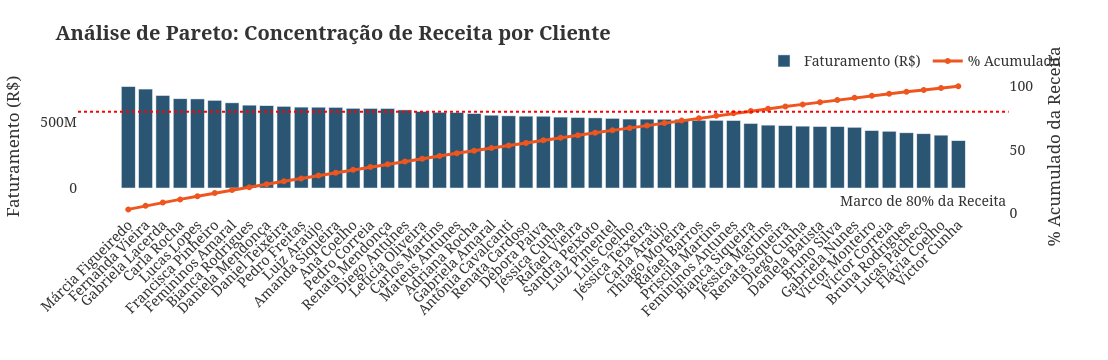

In [8]:

query_pareto = """
-- Table names clarification:
-- df_sales: Represents sales_2023_2024.csv.
-- df_clients: Represents clientes_crm.json.

WITH client_revenue AS (
    SELECT
        id_client,
        SUM(total * qtd) AS total_revenue
    FROM df_sales
    GROUP BY id_client
),
ranked_revenue AS (
    SELECT
        c.full_name AS raw_client_name,
        cr.total_revenue,
        SUM(cr.total_revenue) OVER (ORDER BY cr.total_revenue DESC ROWS BETWEEN UNBOUNDED PRECEDING AND CURRENT ROW) AS cumulative_revenue,
        SUM(cr.total_revenue) OVER () AS grand_total
    FROM client_revenue cr
    INNER JOIN df_clients c 
        ON cr.id_client = c.code
)
SELECT
    raw_client_name,
    total_revenue,
    (cumulative_revenue / grand_total) * 100 AS cumulative_percentage
FROM ranked_revenue
ORDER BY total_revenue DESC;
"""

df_pareto = duckdb.query(query_pareto).df()

def format_professional_name(full_name):
    parts = str(full_name).strip().split()
    
    if len(parts) > 1:
        return f"{parts[0]} {parts[-1]}"

    return full_name

df_pareto['client_name'] = df_pareto['raw_client_name'].apply(format_professional_name)

total_clientes = len(df_pareto)
clientes_80_porcento = len(df_pareto[df_pareto['cumulative_percentage'] <= 80])
concentracao = (clientes_80_porcento / total_clientes) * 100

print("=== RISCO DE CONCENTRAÇÃO ===")
print(f"O faturamento total vem de uma base de {total_clientes} clientes.")
print(f"No entanto, 80% de toda a receita da empresa está concentrada em apenas {clientes_80_porcento} clientes ({concentracao:.1f}% da base).")
if concentracao <= 20:
    print("ALERTA DE RISCO ALTO: A regra de Pareto (80/20) é muito forte aqui. A perda de um top cliente causará grande impacto.")
else:
    print("SAÚDE DA BASE: A receita está bem distribuída e não sofre do risco severo de Pareto.")
print("===========================================================\n")

# ==========================================
# VISUALIZATION
# ==========================================

fig = make_subplots(specs=[[{"secondary_y": True}]])

fig.add_trace(
    go.Bar(
        x=df_pareto['client_name'],
        y=df_pareto['total_revenue'],
        name="Faturamento (R$)",
        marker_color='rgb(42, 86, 116)',
        hovertemplate="Faturamento: R$ %{y:,.2f}<extra></extra>"
    ),
    secondary_y=False,
)

fig.add_trace(
    go.Scatter(
        x=df_pareto['client_name'],
        y=df_pareto['cumulative_percentage'],
        name="% Acumulado",
        mode='lines+markers',
        line=dict(color='rgb(239, 85, 30)', width=3),
        marker=dict(size=6),
        hovertemplate="Acumulado: %{y:.1f}%<extra></extra>"
    ),
    secondary_y=True,
)

fig.update_layout(
    title="<b>Análise de Pareto: Concentração de Receita por Cliente</b>",
    plot_bgcolor="white",
    font=dict(family="Arial", size=14, color="#333333"),
    hovermode="x unified",
    legend=dict(orientation="h", yanchor="bottom", y=1.02, xanchor="right", x=1),
    margin=dict(l=40, r=40, t=80, b=40)
)

fig.update_xaxes(title_text="", showgrid=False, tickangle=-45)
fig.update_yaxes(title_text="Faturamento (R$)", showgrid=False, secondary_y=False)
fig.update_yaxes(title_text="% Acumulado da Receita", range=[0, 105], showgrid=False, secondary_y=True)

fig.add_hline(y=80, line_dash="dot", line_color="red", secondary_y=True, 
              annotation_text="Marco de 80% da Receita", annotation_position="bottom right")

fig.show()

# Parte 2: Diagnóstico de Rentabilidade

Nesta etapa, saímos da visão de faturamento bruto para realizar um raio-X da eficiência da operação da LH Nautical. O objetivo é responder:

- "Quais itens estão corroendo a margem da empresa?"
- "Qual é a taxa de ociosidade da empresa?"

## 2.1 Rank dos Items com Maior Prejuízo

Total de produtos com prejuízo: 150


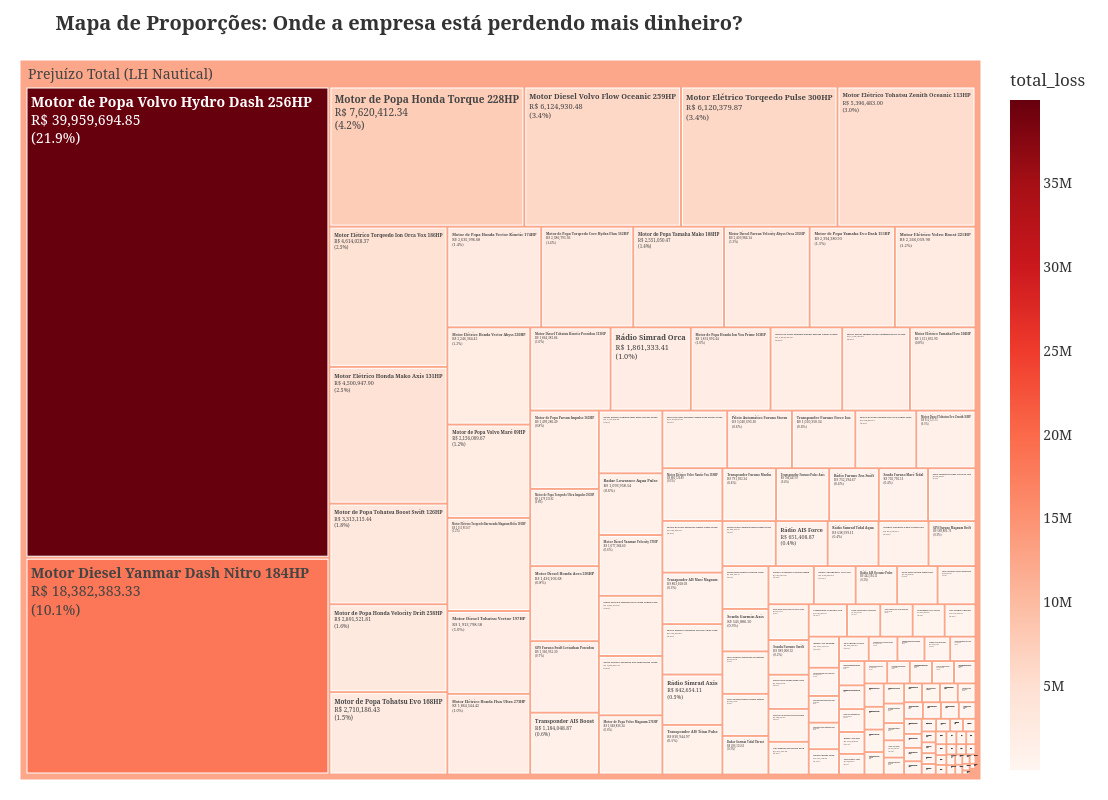

In [15]:
# ==========================================
# DATA PREPARATION
# ==========================================

query_q4 = """
WITH current_costs AS (
    SELECT
        s.id_product,
        s.sale_date,
        s.total AS revenue_brl,
        s.qtd,
        c.usd_price
    FROM df_sales s
    ASOF LEFT JOIN df_costs c
        ON s.id_product = c.product_id
       AND s.sale_date >= c.start_date
),
financial_calc AS (
    SELECT
        cc.id_product,
        cc.revenue_brl,
        fx.usd_rate,
        (cc.usd_price * fx.usd_rate * cc.qtd) AS cost_brl,
        cc.revenue_brl - (cc.usd_price * fx.usd_rate * cc.qtd) AS profit_margin
    FROM current_costs cc
    ASOF LEFT JOIN df_rates fx
        ON cc.sale_date >= fx.rate_date
),
aggregated_metrics AS (
    SELECT
        id_product,
        SUM(revenue_brl) AS raw_revenue,
        SUM(CASE WHEN profit_margin < 0 THEN ABS(profit_margin) ELSE 0 END) AS raw_loss,
        SUM(CASE WHEN profit_margin < 0 THEN ABS(profit_margin) ELSE 0 END) / NULLIF(SUM(revenue_brl), 0) AS raw_loss_pct
    FROM financial_calc
    GROUP BY id_product
)
SELECT
    a.id_product,
    p.name AS product_name,
    ROUND(a.raw_revenue, 2) AS total_revenue,
    ROUND(a.raw_loss, 2) AS total_loss,
    ROUND(a.raw_loss_pct * 100, 2)::VARCHAR || '%' AS loss_percentage
FROM aggregated_metrics a
LEFT JOIN df_products p
    ON a.id_product = p.code
ORDER BY a.raw_loss_pct DESC;
"""

df_fct_profitability = duckdb.query(query_q4).df()

df_loss = df_fct_profitability[df_fct_profitability['total_loss'] > 0].copy()
print(f"Total de produtos com prejuízo: {len(df_loss)}")

# ==========================================
# VISUALIZATION
# ==========================================

fig = px.treemap(
    df_loss,
    path=[px.Constant("Prejuízo Total (LH Nautical)"), 'product_name'],
    values='total_loss',
    color='total_loss',
    color_continuous_scale='Reds',
    title='<b>Mapa de Proporções: Onde a empresa está perdendo mais dinheiro?</b>'
)

fig.update_traces(
    textinfo="label+value+percent parent", 
    texttemplate="<b>%{label}</b><br>R$ %{value:,.2f}<br>(%{percentParent:.1%})",
    hovertemplate="<b>%{label}</b><br>Prejuízo: R$ %{value:,.2f}<extra></extra>"
)

fig.update_layout(
    width=1400,
    height=800,
    margin=dict(t=60, l=20, r=20, b=20),
    font=dict(family="Arial", size=14, color="#333333"),
    template='plotly_white'
)

fig.show()

## 2.2 Taxa de Sangria em relação a receita.

Aqui tentamos enxergar qual é a categoria que mais contribui para o déficit.

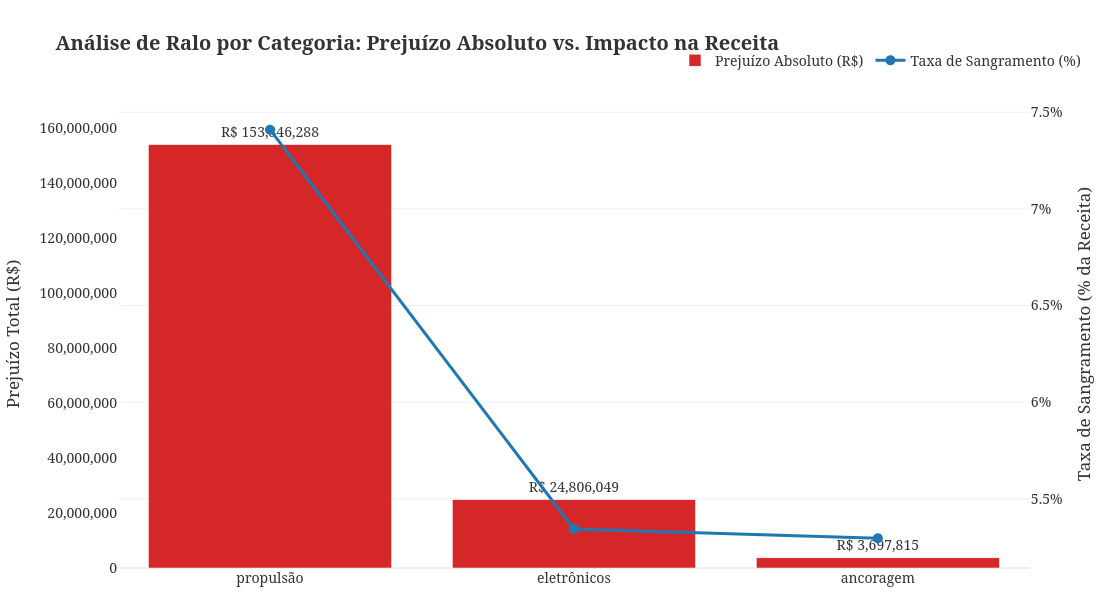

In [10]:
# ==========================================
# DATA PREPARATION
# ==========================================

query_category_drain = """
    SELECT 
        p.actual_category,
        SUM(f.total_revenue) AS total_revenue,
        SUM(f.total_loss) AS total_loss,
        (SUM(f.total_loss) / NULLIF(SUM(f.total_revenue), 0)) * 100 AS drain_rate_pct
    FROM df_fct_profitability f
    JOIN df_products p 
        ON f.id_product = p.code
    WHERE f.total_loss > 0
    GROUP BY p.actual_category
    ORDER BY total_loss DESC
"""

df_category = duckdb.query(query_category_drain).df()

# ==========================================
# VISUALIZATION
# ==========================================

fig = make_subplots(specs=[[{"secondary_y": True}]])

fig.add_trace(
    go.Bar(
        x=df_category['actual_category'],
        y=df_category['total_loss'],
        name="Prejuízo Absoluto (R$)",
        marker_color='#d62728', 
        text=df_category['total_loss'],
        texttemplate='R$ %{text:,.0f}',
        textposition='outside',
        hovertemplate="<b>%{x}</b><br>Prejuízo: R$ %{y:,.2f}<extra></extra>"
    ),
    secondary_y=False,
)

fig.add_trace(
    go.Scatter(
        x=df_category['actual_category'],
        y=df_category['drain_rate_pct'],
        name="Taxa de Sangramento (%)",
        mode='lines+markers',
        line=dict(color='#1f77b4', width=3),
        marker=dict(size=10),
        hovertemplate="<b>%{x}</b><br>Sangramento: %{y:.2f}%<extra></extra>"
    ),
    secondary_y=True,
)

fig.update_layout(
    title='<b>Análise de Ralo por Categoria: Prejuízo Absoluto vs. Impacto na Receita</b>',
    width=1200,
    height=600,
    template='plotly_white',
    hovermode='x unified',
    legend=dict(orientation="h", yanchor="bottom", y=1.05, xanchor="right", x=1),
    margin=dict(t=100, l=20, r=20, b=20),
    font=dict(family="Arial", size=14, color="#333333")
)

fig.update_yaxes(
    title_text="Prejuízo Total (R$)", 
    secondary_y=False, 
    showgrid=False, 
    tickformat=",.0f"
)

fig.update_yaxes(
    title_text="Taxa de Sangramento (% da Receita)", 
    secondary_y=True, 
    showgrid=True, 
    ticksuffix="%"
)

fig.show()

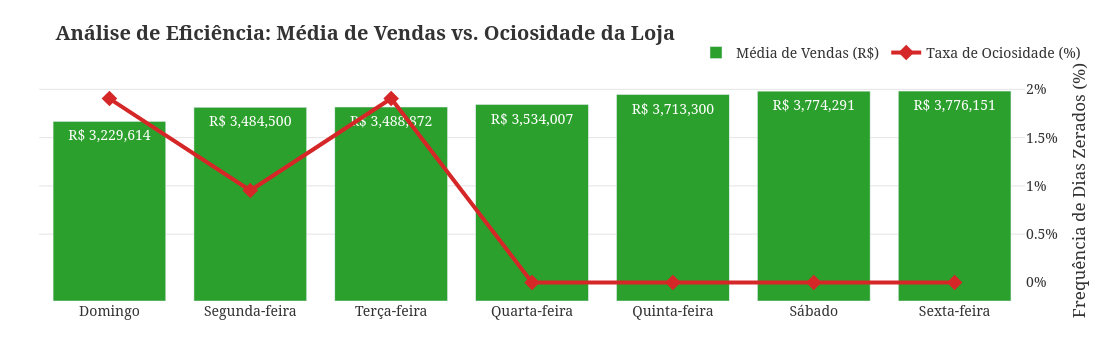


DIAGNÓSTICO:

>> O Domingo e a Terça-feira são os dias de maior risco operacional,
   apresentando os maiores índices de ociosidade (dias sem venda).

---------------------------------------------------------------------------
ANÁLISE DE IMPACTO:
A média de vendas de Domingo era 'artificial', pois ignorava os diversos
   dias em que a loja operou com faturamento zero.



In [11]:
# ==========================================
# DATA PROCESSING
# ==========================================

import plotly.graph_objects as go
from plotly.subplots import make_subplots

query_idle_rate = """
WITH RECURSIVE calendar AS (
    SELECT
        (SELECT MIN(sale_date)::DATE FROM df_sales) as dim_date,
        (SELECT MAX(sale_date)::DATE FROM df_sales) as end_date
    UNION ALL
    SELECT
        (dim_date + INTERVAL '1 day')::DATE AS dim_date,
        end_date
    FROM calendar
    WHERE dim_date < end_date
),
calendar_with_dow AS (
    SELECT
        dim_date,
        CASE DAYOFWEEK(dim_date)
            WHEN 0 THEN 'Domingo'
            WHEN 1 THEN 'Segunda-feira'
            WHEN 2 THEN 'Terça-feira'
            WHEN 3 THEN 'Quarta-feira'
            WHEN 4 THEN 'Quinta-feira'
            WHEN 5 THEN 'Sexta-feira'
            WHEN 6 THEN 'Sábado'
        END AS day_name_pt
    FROM calendar
),
daily_sales AS (
    SELECT
        sale_date,
        SUM(total) AS daily_revenue
    FROM df_sales
    GROUP BY sale_date
),
calendar_joined AS (
    SELECT
        c.dim_date,
        c.day_name_pt,
        COALESCE(ds.daily_revenue, 0) AS final_daily_revenue,
        CASE WHEN ds.daily_revenue IS NULL THEN 1 ELSE 0 END AS is_idle
    FROM calendar_with_dow c
    LEFT JOIN daily_sales ds
        ON c.dim_date = ds.sale_date
)
SELECT 
    day_name_pt,
    AVG(final_daily_revenue) AS true_average_sales,
    (SUM(is_idle) * 100.0) / COUNT(dim_date) AS idle_rate_pct
FROM calendar_joined
GROUP BY day_name_pt
ORDER BY true_average_sales ASC;
"""

df_idle = duckdb.query(query_idle_rate).df()

# ==========================================
# VISUALIZATION
# ==========================================

fig = make_subplots(specs=[[{"secondary_y": True}]])

fig.add_trace(
    go.Bar(
        x=df_idle['day_name_pt'],
        y=df_idle['true_average_sales'],
        name="Média de Vendas (R$)",
        marker_color='#2ca02c',
        text=df_idle['true_average_sales'],
        texttemplate='R$ %{text:,.0f}',
        textposition='inside',
        insidetextanchor='end',
        hovertemplate="<b>%{x}</b><br>Média: R$ %{y:,.2f}<extra></extra>"
    ),
    secondary_y=False,
)

fig.add_trace(
    go.Scatter(
        x=df_idle['day_name_pt'],
        y=df_idle['idle_rate_pct'],
        name="Taxa de Ociosidade (%)",
        mode='lines+markers',
        line=dict(color='#d62728', width=4),
        marker=dict(size=12, symbol='diamond'),
        hovertemplate="<b>%{x}</b><br>Dias sem venda: %{y:.1f}%<extra></extra>"
    ),
    secondary_y=True,
)

fig.update_layout(
    title='<b>Análise de Eficiência: Média de Vendas vs. Ociosidade da Loja</b>',
    plot_bgcolor="white",
    font=dict(family="Arial", size=14, color="#333333"),
    hovermode='x unified',
    legend=dict(orientation="h", yanchor="bottom", y=1.05, xanchor="right", x=1),
    margin=dict(t=80, l=20, r=20, b=20)
)

fig.update_yaxes(title_text="", showticklabels=False, showgrid=False, secondary_y=False)
fig.update_yaxes(title_text="Frequência de Dias Zerados (%)", showgrid=True, gridcolor="#e5e5e5", ticksuffix="%", secondary_y=True)
fig.update_xaxes(title="")

fig.show()

# ==========================================
# DIAGNOSTIC
# ==========================================

print("\n" + "="*75)
print("DIAGNÓSTICO:")
print("="*75 + "\n")
print(">> O Domingo e a Terça-feira são os dias de maior risco operacional,")
print("   apresentando os maiores índices de ociosidade (dias sem venda).\n")

print("-" * 75)
print("ANÁLISE DE IMPACTO:")
print("A média de vendas de Domingo era 'artificial', pois ignorava os diversos")
print("   dias em que a loja operou com faturamento zero.")
print("="*75 + "\n")

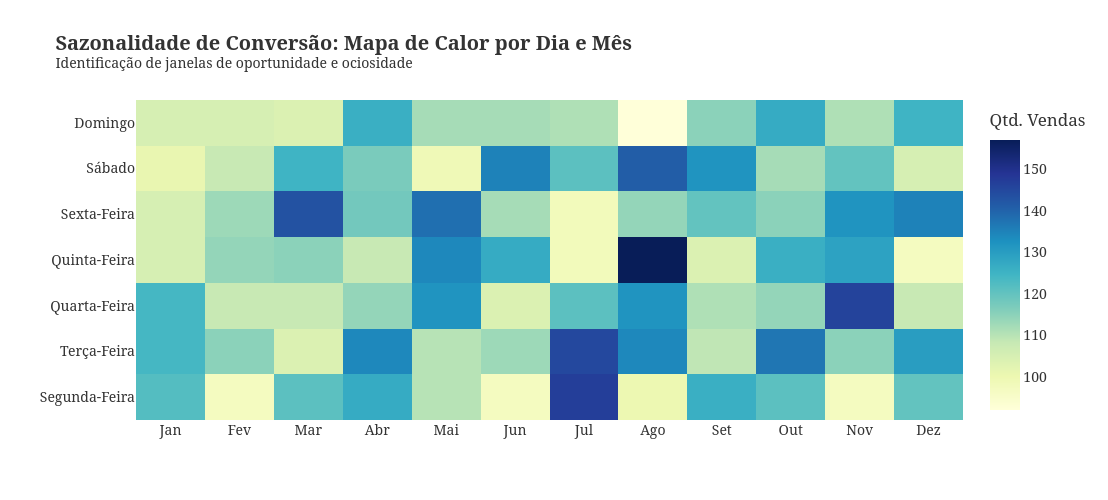


 DIAGNÓSTICO 

INSIGHT PRINCIPAL:
>> O maior volume de conversão ocorre historicamente aos meses de pico,
   especialmente no mês 8 (Ago).

ESTRATÉGIA SUGERIDA:
>> Utilizar os 'buracos' (áreas claras no mapa) para campanhas de ativação
específicas, focando em converter a ociosidade das terças e domingos.



In [12]:
# ==========================================
# DATA PREPARATION
# ==========================================

query_heatmap = """
-- Table names clarification:
-- df_sales: Represents sales_2023_2024.csv.

SELECT 
    month(sale_date) AS month_idx,
    CASE dayofweek(sale_date)
        WHEN 0 THEN '7. Domingo'
        WHEN 1 THEN '1. Segunda-Feira'
        WHEN 2 THEN '2. Terça-Feira'
        WHEN 3 THEN '3. Quarta-Feira'
        WHEN 4 THEN '4. Quinta-Feira'
        WHEN 5 THEN '5. Sexta-Feira'
        WHEN 6 THEN '6. Sábado'
    END AS day_name,
    COUNT(id) AS sales_count
FROM df_sales
GROUP BY 1, 2
ORDER BY 1, 2
"""

df_heatmap_raw = duckdb.query(query_heatmap).df()
df_pivot = df_heatmap_raw.pivot(index='day_name', columns='month_idx', values='sales_count').fillna(0)

months_pt = {
    1: 'Jan', 2: 'Fev', 3: 'Mar', 4: 'Abr', 5: 'Mai', 6: 'Jun',
    7: 'Jul', 8: 'Ago', 9: 'Set', 10: 'Out', 11: 'Nov', 12: 'Dez'
}
display_months = [months_pt[m] for m in df_pivot.columns]
display_days = [d.split('. ')[1] for d in df_pivot.index]

# ==========================================
# VISUALIZATION
# ==========================================

fig = go.Figure(data=go.Heatmap(
    z=df_pivot.values,
    x=display_months,
    y=display_days,
    colorscale='YlGnBu',
    showscale=True,
    colorbar=dict(title="Qtd. Vendas"),
    hovertemplate="<b>%{y}</b> em <b>%{x}</b><br>Total de Vendas: %{z}<extra></extra>"
))

fig.update_layout(
    title='<b>Sazonalidade de Conversão: Mapa de Calor por Dia e Mês</b><br><sup>Identificação de janelas de oportunidade e ociosidade</sup>',
    xaxis_title="",
    yaxis_title="",
    font=dict(family="Arial", size=14, color="#333333"),
    width=900,
    height=500,
    plot_bgcolor='white'
)

fig.show()

# ==========================================
# DIAGNOSTIC
# ==========================================

print("\n" + "="*75)
print(" DIAGNÓSTICO ")
print("="*75 + "\n")

if not df_heatmap_raw.empty:
    peak = df_heatmap_raw.loc[df_heatmap_raw['sales_count'].idxmax()]
    print(f"INSIGHT PRINCIPAL:")
    print(f">> O maior volume de conversão ocorre historicamente aos meses de pico,")
    print(f"   especialmente no mês {peak['month_idx']} ({months_pt[peak['month_idx']]}).")
    print(f"\nESTRATÉGIA SUGERIDA:")
    print(">> Utilizar os 'buracos' (áreas claras no mapa) para campanhas de ativação")
    print("específicas, focando em converter a ociosidade das terças e domingos.")
    print("="*75 + "\n")

## 4.1 Previsão de Demanda: Motor de Popa Yamaha (Q7)

Nesta etapa, construímos um modelo de **Baseline** para prever as vendas diárias do produto "Motor de Popa Yamaha Evo Dash 155HP". O objetivo é avaliar se uma média móvel simples é capaz de suportar as decisões de estoque para o mês de Janeiro de 2024.

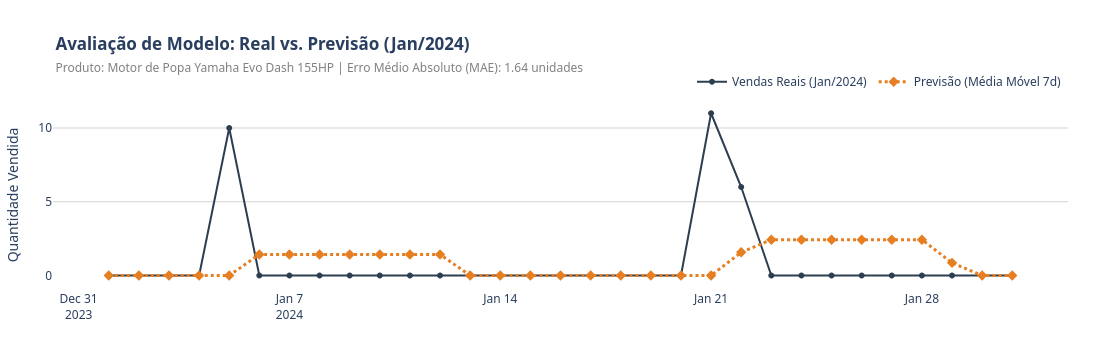

In [13]:
# ==========================================
# DATA PROCESSING
# ==========================================

target_product = "Motor de Popa Yamaha Evo Dash 155HP"
product_id = df_products[df_products['name'] == target_product]['code'].iloc[0]

df_target_sales = df_sales[df_sales['id_product'] == product_id].copy()
df_target_sales['sale_date'] = pd.to_datetime(df_target_sales['sale_date'])

all_dates = pd.date_range(start='2023-01-01', end='2024-01-31')
daily_series = df_target_sales.groupby('sale_date')['qtd'].sum().reindex(all_dates, fill_value=0).reset_index()
daily_series.columns = ['date', 'actual_qty']

daily_series['forecast'] = daily_series['actual_qty'].shift(1).rolling(window=7).mean()

df_test = daily_series[(daily_series['date'] >= '2024-01-01') & (daily_series['date'] <= '2024-01-31')].copy()

mae = mean_absolute_error(df_test['actual_qty'], df_test['forecast'])

# ==========================================
# VISUALIZATION
# ==========================================

fig_forecast = go.Figure()

fig_forecast.add_trace(go.Scatter(
    x=df_test['date'], y=df_test['actual_qty'],
    name='Vendas Reais (Jan/2024)',
    mode='lines+markers',
    line=dict(color='#2C3E50', width=2),
    marker=dict(size=6)
))


fig_forecast.add_trace(go.Scatter(
    x=df_test['date'], y=df_test['forecast'],
    name='Previsão (Média Móvel 7d)',
    mode='lines+markers',
    line=dict(color='#E67E22', width=3, dash='dot'),
    marker=dict(symbol='diamond', size=8)
))

fig_forecast.update_layout(
    title=f"<b>Avaliação de Modelo: Real vs. Previsão (Jan/2024)</b><br>" +
          f"<span style='font-size:12px; color:gray;'>Produto: {target_product} | Erro Médio Absoluto (MAE): {mae:.2f} unidades</span>",
    xaxis_title="", yaxis_title="Quantidade Vendida",
    plot_bgcolor='white',
    hovermode='x unified',
    legend=dict(orientation="h", yanchor="bottom", y=1.02, xanchor="right", x=1),
    margin=dict(t=100, b=40, l=40, r=40)
)

fig_forecast.update_yaxes(showgrid=True, gridcolor='lightgrey')
fig_forecast.show()

### 4.2 Vitrine Inteligente.

Durante a jornada de compra, é comum que clientes esqueçam itens complementares essenciais (ex: comprar uma lancha e esquecer as defensas). Para maximizar o *cross-sell* (venda cruzada) e melhorar a experiência do usuário sem depender de ferramentas custosas de Big Data, desenvolvemos um motor de recomendação interno.

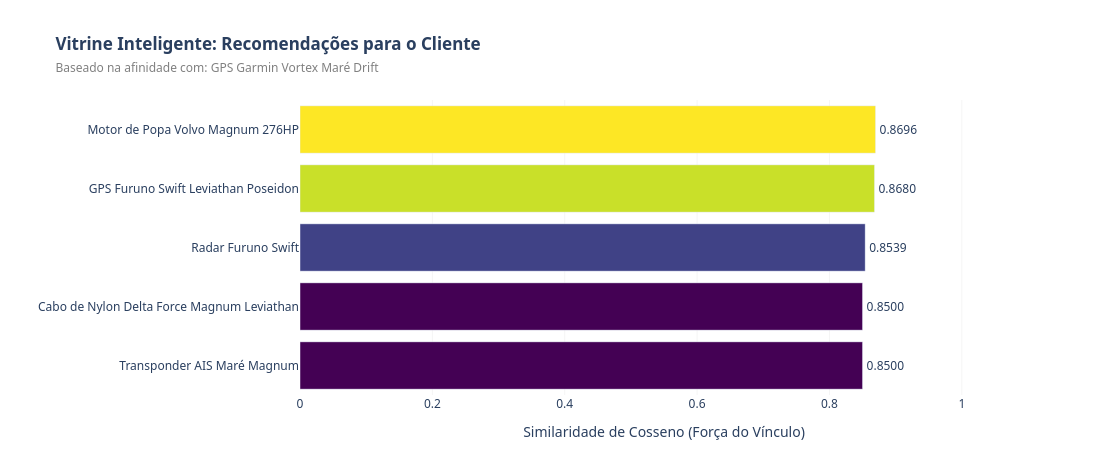

In [14]:
# ==========================================
# DATA PROCESSING
# ==========================================

target_product = df_products[df_products['name'].str.contains('GPS Garmin Vortex Maré Drift', case=False, na=False)]

target_id = target_product['code'].iloc[0]
target_name = target_product['name'].iloc[0]

user_item_matrix = pd.crosstab(df_sales['id_client'], df_sales['id_product'])
user_item_matrix = (user_item_matrix > 0).astype(int)

item_item_sim_matrix = cosine_similarity(user_item_matrix.T)

df_similarity = pd.DataFrame(
    item_item_sim_matrix, 
    index=user_item_matrix.columns, 
    columns=user_item_matrix.columns
)

similar_scores = df_similarity[target_id].drop(target_id)

top_5_similar = similar_scores.sort_values(ascending=False).head(5).reset_index()
top_5_similar.columns = ['id_product', 'cosine_similarity']

top_5_df = top_5_similar.merge(
    df_products[['code', 'name']], 
    left_on='id_product', 
    right_on='code', 
    how='left'
)

# ==========================================
# VISUALIZATION
# ==========================================

df_plot_sim = top_5_df.sort_values(by='cosine_similarity', ascending=True)

fig_rec = go.Figure()

fig_rec.add_trace(go.Bar(
    y=df_plot_sim['name'],
    x=df_plot_sim['cosine_similarity'],
    orientation='h',
    marker=dict(
        color=df_plot_sim['cosine_similarity'],
        colorscale='Viridis',
        showscale=False
    ),
    text=df_plot_sim['cosine_similarity'],
    texttemplate='%{text:.4f}',
    textposition='outside',
    hovertemplate="<b>%{y}</b><br>Score de Afinidade: %{x:.4f}<extra></extra>"
))

fig_rec.update_layout(
    title=f"<b>Vitrine Inteligente: Recomendações para o Cliente</b><br>" +
          f"<span style='font-size:12px; color:gray;'>Baseado na afinidade com: {target_name}</span>",
    plot_bgcolor='white',
    height=450,
    margin=dict(t=100, l=20, r=80, b=40),
    xaxis=dict(
        title="Similaridade de Cosseno (Força do Vínculo)",
        range=[0, 1.1],
        showgrid=True,
        gridcolor='whitesmoke'
    ),
    yaxis=dict(title="")
)

fig_rec.show()

print 